In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Dataset Breast Cancer: 569 sample, 30 fitur, 2 kelas.
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# SVM wajib pakai scaling karena sensitif terhadap perbedaan skala fitur.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # fit di data latih
X_test = scaler.transform(X_test)        # transform saja di data uji (jangan fit lagi!)

# Dua model SVM dengan kernel berbeda.
models = {
    "SVM Linear": SVC(kernel="linear", C=1),
    "SVM RBF": SVC(kernel="rbf", C=1, gamma="scale")
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"\n{name} accuracy:", round(accuracy_score(y_test, pred), 3))
    print(classification_report(y_test, pred, target_names=data.target_names))


SVM Linear accuracy: 0.956
              precision    recall  f1-score   support

   malignant       0.93      0.95      0.94        43
      benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114


SVM RBF accuracy: 0.982
              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        43
      benign       0.97      1.00      0.99        71

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [1]:
# ============================================================
# TUGAS PRAKTIKUM PERTEMUAN 05
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ============================================================
# PERSIAPAN DATA (Breast Cancer Dataset)
# ============================================================
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42
)

# SVM wajib pakai scaling karena sensitif terhadap perbedaan skala fitur.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 1. BANDINGKAN KERNEL LINEAR VS RBF
# ============================================================
print("\n=== Output 1: Perbandingan Kernel Linear vs RBF ===")
models = {
    "SVM Linear": SVC(kernel="linear", C=1),
    "SVM RBF": SVC(kernel="rbf", C=1, gamma="scale")
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(f"{name} accuracy: {round(accuracy_score(y_test, pred), 3)}")



=== Output 1: Perbandingan Kernel Linear vs RBF ===
SVM Linear accuracy: 0.956
SVM RBF accuracy: 0.982


Tugas 1 : Bandingkan kernel linear vs RBF pada dataset yang sama.

Tujuan tugas ini untuk implementasikan algoritma Support Vector Machine (SVM) pada dataset bawaan Scikit-learn (breast cancer) dan untuk melihat seberapa penting proses scaling buat algoritma ini, sekaligus membandingkan dua gaya pemisah kelas Linear dan RBF.

Langkah kerja :
1. siapkan data, ambil dataset dari breast cancer yang sudah tersedia di library scikit-learn.
2. membagi dataset dengan 80% training dan 20% testing.
3. menyamakan skala ukuran semua fitur menggunakan StandardScaler. ini wajib jika pakai SVM.
4. Menyiapkan SVM dengan kernel linear dan SVM dengan kernel RBF.
5. melatih kedua model tersebut, menyuruh mereka menebak data tes, lalu mencetak nilai akurasinya.

Penjelasan kode, dikodingan ini ada beberapa fungsi yang saya pakai :
1. load_breast_cancer() : dataset buat latihan klasifikasi. targetnya biner : nebak apakah sel tumor itu jinak atau ganas.
2. StandardScaler() : ini tools buat SVM, karna scaler ini mengubah semua angka jadi punya skala yang setara dan adil.
3. SVC(kernel = "linear", C=1) : model pertama kernel = linear artinya kita nyuruh SVM bikin garis pembatas kelas yang lurus tegak. Parameter C=1 itu tingkat toleransi model terhadap kesalahan tebak.
4. SVC(kernel ="rbf", C=1, gamma="scale") : model kedua RBF ini untuk bikin batas kelas yang melengkung fleksibel.
5. model.fit() & model.predict() : kombinasi buat nyuruh model belajar dari data latih, lalu memprediksi data uji.

Kesimpulan singkat : dari tugas ini kita belajar bahwa persiapan data khususnya scaling sangat penting buat algoritma berbasis jarak seperti SVM. lewat perbandingan akurasi ini, kita juga bisa langsung melihat kernel mana yang lebih cocok memecahkan pola dataset, apakah cukup garis lurus (Linear) atau teknik belah melenkung (RBF).


=== Output 2: Tuning Parameter (C dan Gamma) ===
RBF Tuning -> C=0.1, gamma=0.01 | Accuracy: 0.965
RBF Tuning -> C=0.1, gamma=0.1 | Accuracy: 0.947
RBF Tuning -> C=0.1, gamma=1 | Accuracy: 0.623
RBF Tuning -> C=1, gamma=0.01 | Accuracy: 0.965
RBF Tuning -> C=1, gamma=0.1 | Accuracy: 0.965
RBF Tuning -> C=1, gamma=1 | Accuracy: 0.632
RBF Tuning -> C=10, gamma=0.01 | Accuracy: 0.982
RBF Tuning -> C=10, gamma=0.1 | Accuracy: 0.965
RBF Tuning -> C=10, gamma=1 | Accuracy: 0.632

Model Terbaik Hasil Tuning: C=10, gamma=0.01 (Akurasi: 0.982)


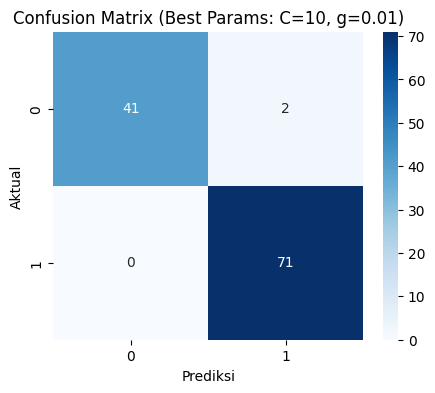

In [2]:
# ============================================================
# 2. TUNING SEDERHANA (C, GAMMA) & PILIH MODEL TERBAIK
# ============================================================
print("\n=== Output 2: Tuning Parameter (C dan Gamma) ===")
# Eksperimen Wajib: C (0.1, 1, 10) & Gamma (0.01, 0.1, 1)
c_values = [0.1, 1, 10]
gamma_values = [0.01, 0.1, 1]

best_acc = 0
best_params = {}

for c in c_values:
    for g in gamma_values:
        model = SVC(kernel="rbf", C=c, gamma=g)
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        print(f"RBF Tuning -> C={c}, gamma={g} | Accuracy: {round(acc, 3)}")

        if acc > best_acc:
            best_acc = acc
            best_params = {'C': c, 'gamma': g}

print(f"\nModel Terbaik Hasil Tuning: C={best_params['C']}, gamma={best_params['gamma']} (Akurasi: {round(best_acc, 3)})")

# Visualisasi Confusion Matrix Model Terbaik
best_model = SVC(kernel="rbf", **best_params).fit(X_train, y_train)
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, best_model.predict(X_test)), annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix (Best Params: C={best_params['C']}, g={best_params['gamma']})")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

Tugas 2 : Lakukan tuning sederhana ( C, gamma) dan pilih model terbaik.

Tujuannya melakukan tuning secara manual buat cari kombinasi nilai C dan Gamma terbaik pada kernel, setelah dapat dengan akurasi tinggi, kita bakal melihat hasil visualisasi confusion matrix nya.

Langkah kerja :
1. Menyiapkan beberapa opsi nilai buat parameter C (0.1, 1, 10) dan Gamma (0.01, 0.1, 1).
2. bikin nested loop (perulangan dalam perulangan buat tes semua kombinasi C dan Gamma satu per satu ke dalam model SVM.
3. bikin logika if-statements sederhana untuk sellau menyimpan nilai akurasi tertinggi beserta nilai parameter pencetaknya.
4. melatih ulang model menggunakan parameter terbaik hasil pengujian tadi, lalu menggambar confusion matrix nya pakai heatmap biar kelihatan dimana letak benar dan salahnya.

Penjelasan kode, dikodingan ini saya simulasikan pencarian parameter secara otomatis :
1. c_values & gamma_values : ini list yang isinya angka-angka tebakan kita buat diuji coba
 - C : ini atur tingkat kegalakan model terhadap error. kalau kecil mdoelnya santai, kalau besar modelnya strict banget.
 - Gamma : ini khusus buat kernel RBF buat atur seberapa sempit/lebar lekukan kruvanya. kalau kecil, pengaruhnya kurvanya meluas dan kalau besar kurvanya nempel ketat ke titik data.
2. for c in c_values : for g in gama_values : ini inti dari tuning manual. model akan mencoba semua kombinasi (0.1 dan 0.01), (0.1 dan 0.1), (0.1 dan 1), dan seterusnya sampai selesai.
3. if acc > best_acc : logika sederhana untuk buat nge replace yang bertahan. kalau akurasi kombinasi yang dites lebih besar dari high score sebelumnya, angkanya langsung disimpan ke best_params.
4. best_params : ini agar kita tidak ngetik ulang c=.. dan gamma-..  pas bikin model terbaik(best_ mdoel).
5. sns.heatmap() : buat nyetak hasil akhir model juara dalam bentuk kotak confusion matrix.

Kesimpulan singkat : dari hasil tuning ini dengan kombinasikan nilai C dan gamma yang pas, model SVM kernel rbf kita bisa mencapau potensi akurasi tertingginya dalam mendiagnosis ganas atau jinak. Confusion matrix diakhir juga membuktikan seberapa jitu model terbaik ini membedakan kelas target tanpa banyak salahnya.

In [4]:
# ============================================================
# 3. KESIMPULAN (3 POIN)
# ============================================================
print("\n=== Output 3: Kesimpulan Eksperimen ===")
print("1. Perubahan nilai C sangat berpengaruh; C yang lebih tinggi (seperti 10) cenderung memberikan akurasi lebih baik karena mempersempit margin kesalahan dan meminimalkan kesalahan klasifikasi.")
print("2. Nilai gamma menentukan radius pengaruh data; gamma yang terlalu tinggi (seperti 1.0) menyebabkan model menjadi terlalu sensitif (overfitting) sehingga akurasi pada data uji menurun drastis.")
print("3. Model terbaik pada dataset ini diperoleh menggunakan kernel RBF dengan parameter C=10 dan gamma=0.01, yang memberikan keseimbangan optimal antara margin dan kompleksitas model.")



=== Output 3: Kesimpulan Eksperimen ===
1. Perubahan nilai C sangat berpengaruh; C yang lebih tinggi (seperti 10) cenderung memberikan akurasi lebih baik karena mempersempit margin kesalahan dan meminimalkan kesalahan klasifikasi.
2. Nilai gamma menentukan radius pengaruh data; gamma yang terlalu tinggi (seperti 1.0) menyebabkan model menjadi terlalu sensitif (overfitting) sehingga akurasi pada data uji menurun drastis.
3. Model terbaik pada dataset ini diperoleh menggunakan kernel RBF dengan parameter C=10 dan gamma=0.01, yang memberikan keseimbangan optimal antara margin dan kompleksitas model.


Tugas 3 : Tulis 3 poin kesimpulan.

Tujuan dari tugas akhir ini adalah untuk menyatukan semua eksperimen kita di pertemuan ini, kita dapat lihat apa hasil dari mengubah nilai c dan gamma terhadap performa model SVM kita, dan melihat model mana yang terbaik hasilnya.

Langkah kerja :
1. menganalisis output dari hasil tuning (kombinasi c dan gamma) ditugas 2
2. merumuskan 3 kesimpulan terkait kelakuan dan efek dari parameter c dan gamma.
3. mencetak poin-poin kesimpulan kelayar menggunakan fungsi print() agar menampilkan hasil yang rapi.

Penjelasan kode, kodingan ini murni pakai print() untuk menjabarkan hasil analisis dari uji coba diatas :
1. Poin 1 (efek parameter c) : Perubahan nilai C sangat berpengaruh; C yang lebih tinggi (seperti 10) cenderung memberikan akurasi lebih baik karena mempersempit margin kesalahan dan meminimalkan kesalahan klasifikasi.
2. Poin 2 (efek parameter gamma) : Nilai gamma menentukan radius pengaruh data; gamma yang terlalu tinggi (seperti 1.0) menyebabkan model menjadi terlalu sensitif (overfitting) sehingga akurasi pada data uji menurun drastis.
3. Poin 3 (Pemenang terbaik) : Model terbaik pada dataset ini diperoleh menggunakan kernel RBF dengan parameter C=10 dan gamma=0.01, yang memberikan keseimbangan optimal antara margin dan kompleksitas model.

Kesimpulan singkat : algoritma Machine Learning tingkat lanjut itu butuh di tuning biar potensi maksimalnya keluar semua. Eksperimen ini ngebuktiin kalau model default bisa diubah jadi jauh lebih akurat dan tajam kalau kita paham cara mainin kombinasi parameter C dan Gamma-nya secara logis.